<div align="center">
  <img src="../data/logo.png" alt="Logo" width="300">
	<p>Mapping in Python, the way it was always meant to be.</p>
</div>

# **PRESENTATION**

Cartograpy est un package python qui permet de manipuler des données geographiques et de creer des cartes simplement.

<div align="center">
  <img src="../data/create_python_maps.py.png" alt="Logo" width="800">
	<p>And you have all you need !</p>
</div>



# **FONCTIONNALITE**
- Telecharger des données de découpage administratif de pays
- Importer des données de types vectorielles et matricielles
- Faire des traitement sur les données geospatiales importé
- Creer des cartes et les personnaliser simplement

# **INSTALLATION**

Pour installer le package cartograpy, vous pouvez utiliser pip. Ouvrez votre terminal ou invite de commande et exécutez la commande suivante :

```bash
pip install cartograpy
```

# **UTILISATION**


## **Obtension de données géographiques**

### *Récupérer les limites administratives d'un ou plusieurs pays*

In [2]:
# Importation
from cartograpy import data
from cartograpy.styling import *
client = data.GeoBoundaries()
# import matplotx

# from qbstyles import mpl_style

# mpl_style(dark=True)

ModuleNotFoundError: No module named 'cartograpy'

**Les niveau de subbdivision administrative disponibles sont :**

Il existe 5 subdivisions administratives disponibles :

In [ ]:
print(client.adminLevels())


| Niveau GeoBoundaries | Nom commun (FR)           | Nom commun (EN)       |
| -------------------- | ------------------------- | --------------------- |
| ADM0                 | Pays                      | Country               |
| ADM1                 | Région / État / Province  | State / Region        |
| ADM2                 | Département / District    | District / County     |
| ADM3                 | Sous-préfecture / Commune | Subdistrict / Commune |
| ADM4                 | Village / Localité        | Village / Locality    |
| ADM5                 | Quartier / Secteur        | Neighborhood / Sector |
        


**Remarques importantes :**

- Le nombre de niveaux dépend du pays. Certains pays s’arrêtent à ADM2, d’autres vont jusqu’à ADM4 ou ADM5.
- Le nom réel des subdivisions varie d’un pays à l’autre (ex : “State”, “Region”, “Province”, “Department”, etc.).
- GeoBoundaries propose toujours au moins le niveau ADM0 (frontière nationale).

Pour savoir si un niveau administratif est disponible pour un pays, vous pouvez utiliser la méthode `is_valid_adm` de l'objet `GeoBoundaries`. 
Voici un exemple :

In [ ]:
# print(client.is_valid_adm("CIV","ADM1"))  # Exemple pour vérifier si le niveau ADM1 est valide pour la Côte d'Ivoire
# Ou encore
print(client._get_smallest_adm("CIV"))  # Exemple pour vérifier si le niveau admin minimum pour la Côte d'Ivoire

Smallest ADM level found for CIV : ADM3
ADM3


**Les codes des pays sont conformes à la norme ISO 3166-1 alpha-3 :**

Pour obtenir la liste des pays valides, vous pouvez utiliser la méthode `countries()` de l'objet `GeoBoundaries`. 
Voici un exemple :

In [ ]:
client.list_countries()[0:10]  # Affiche les 10 premiers pays

['أفغانستان',
 'афганистан',
 'afghánistán',
 'afghanistan',
 'αφγανιστάν',
 'afganio',
 'afganistán',
 'afganistan',
 'afganisztán',
 'աֆղանստան']

In [ ]:
client.get_iso3("burk")

'BFA'

In [ ]:
client.get_iso3("con")  # Exemple pour obtenir le code ISO d'un pays

[('congo', 'cog'),
 ('república del congo', 'cog'),
 ('république du congo', 'cog'),
 ('rep. del congo', 'cog'),
 ('congo-brazzaville', 'cog'),
 ('república do congo', 'cog'),
 ('demokratiske republik congo', 'cod'),
 ('congo, democratic republic of the', 'cod'),
 ('república democrática del congo', 'cod'),
 ('république démocratique du congo', 'cod'),
 ('rd del congo', 'cod'),
 ('congo-kinshasa', 'cod'),
 ('república democrática do congo', 'cod'),
 ('republica democrată congo', 'cod')]

In [ ]:

# Exemple 1: Récupérer les données administratives des régions de la cote d'ivoire
civ_data = client.adm("CIV", "ADM2")
civ_data.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-4.68451 6.27179, -4.6868 6.26883, -...",Agneby-Tiassa,,98640826B52449815511854,CIV,ADM2
1,"POLYGON ((-7.71925 9.07004, -7.72574 9.06397, ...",Bafing,,98640826B37750272367318,CIV,ADM2
2,"POLYGON ((-6.19702 10.24246, -6.20038 10.24495...",Bagoue,,98640826B26044148659027,CIV,ADM2
3,"MULTIPOLYGON (((-4.68451 6.27179, -4.68338 6.2...",Belier,,98640826B5123145245776,CIV,ADM2
4,"POLYGON ((-6.70042 9.06196, -6.70118 9.05639, ...",Bere,,98640826B43857880322183,CIV,ADM2


In [ ]:
# Exemple 2 : Récupérer les limites administratives de plusieurs pays (senegal et mali ici)
countries_data = client.adm(["SEN", "mali"], "ADM2")
countries_data["mali"].head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-7.92938 12.68171, -7.93554 12.68821...",Bamako,,8926073B70420899930674,MLI,ADM2
1,"POLYGON ((1.32448 16.90639, 1.03227 16.61402, ...",Ansongo,,8926073B56917716124995,MLI,ADM2
2,"POLYGON ((1.17767 17.69958, 1.15458 17.70648, ...",Bourem,,8926073B86504284097699,MLI,ADM2
3,"POLYGON ((1.32448 16.90639, 1.65353 17.5735, 1...",Gao,,8926073B84061132695750,MLI,ADM2
4,"POLYGON ((1.31144 15.27381, 1.4716 15.28167, 1...",Menaka,,8926073B3742503303790,MLI,ADM2


### Récupérer les métadonnées d'un territoire

In [ ]:

# Récupérer les métadonnées d'un territoire
metadata_civ = client.metadata("CIV", "ADM0")


print(f"Métadonnées disponibles pour la Côte d'Ivoire: {metadata_civ.keys()}")


Métadonnées disponibles pour la Côte d'Ivoire: dict_keys(['boundaryID', 'boundaryName', 'boundaryISO', 'boundaryYearRepresented', 'boundaryType', 'boundaryCanonical', 'boundarySource', 'boundaryLicense', 'licenseDetail', 'licenseSource', 'boundarySourceURL', 'sourceDataUpdateDate', 'buildDate', 'Continent', 'UNSDG-region', 'UNSDG-subregion', 'worldBankIncomeGroup', 'admUnitCount', 'meanVertices', 'minVertices', 'maxVertices', 'meanPerimeterLengthKM', 'minPerimeterLengthKM', 'maxPerimeterLengthKM', 'meanAreaSqKM', 'minAreaSqKM', 'maxAreaSqKM', 'staticDownloadLink', 'gjDownloadURL', 'tjDownloadURL', 'imagePreview', 'simplifiedGeometryGeoJSON'])


In [ ]:
metadata_civ["Continent"]

'Africa'

In [ ]:
metadata_civ["UNSDG-subregion"]

'Western Africa'

In [ ]:
metadata_civ["UNSDG-region"]

'Sub-Saharan Africa'

In [ ]:
url_img=metadata_civ["imagePreview"]
url_img

'https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/CIV/ADM0/geoBoundaries-CIV-ADM0-PREVIEW.png'

In [ ]:
# Afficher l'image de prévisualisation dans le notebook
from IPython.display import Image, display

try :
    display(Image(url=url_img))
except :
    print("Impossible d'afficher l'image.")

### *Géocoder une ou plusieurs adresses*

Le geocodage permet de convertir des adresses en coordonnées géographiques (latitude et longitude).
Vous pouvez géocoder une ou plusieurs adresses en utilisant les méthode `geocode` et `geocode_batch` de l'objet `Geocoder`.

In [ ]:
from cartograpy import data
geocoder= data.Geocoder()

**Géocoder une adresse**


In [ ]:
address = "bouaké"
result = geocoder.geocode(address)

# Adresse trouvée
result[0]

Début du géocodage de 1 localité(s)...
Géocodage terminé.


,query,address,latitude,longitude,altitude,raw,geometry
0,bouaké,"Bouaké, Gbêkê, Vallée du Bandama, Côte d’Ivoire",7.689021,-5.028355,0.0,"{'place_id': 277030935, 'licence': 'Data © Ope...",POINT (-5.02836 7.68902)


In [ ]:
# Adresse non trouvée
result[1]

[]

**Geocoder une liste d'adresses**

In [ ]:
liste_adresses = ["Abidjan", "Yamoussoukro", "Bouaké", "Korhogo","Man CI", "","portbouet"]
results=geocoder.geocode(liste_adresses)

# Adresses trouvées
results[0]

Début du géocodage de 7 localité(s)...
Géocodage terminé.


,query,address,latitude,longitude,altitude,raw,geometry
0,Abidjan,"Abidjan, Côte d’Ivoire",5.320357,-4.016107,0.0,"{'place_id': 275432765, 'licence': 'Data © Ope...",POINT (-4.01611 5.32036)
1,Yamoussoukro,"Yamoussoukro, Côte d’Ivoire",6.820007,-5.277603,0.0,"{'place_id': 405167260, 'licence': 'Data © Ope...",POINT (-5.2776 6.82001)
2,Bouaké,"Bouaké, Gbêkê, Vallée du Bandama, Côte d’Ivoire",7.689021,-5.028355,0.0,"{'place_id': 277030935, 'licence': 'Data © Ope...",POINT (-5.02836 7.68902)
3,Korhogo,"Korhogo, Poro, Savanes, Côte d’Ivoire",9.458070,-5.631629,0.0,"{'place_id': 275218468, 'licence': 'Data © Ope...",POINT (-5.63163 9.45807)
4,Man CI,"Man, Tonkpi, Montagnes, Côte d’Ivoire",7.410258,-7.550372,0.0,"{'place_id': 275770928, 'licence': 'Data © Ope...",POINT (-7.55037 7.41026)


In [ ]:
# Adresses non trouvée
results[1]

['', 'portbouet']

## **Processing de données**

`processing` vous permet d'executer des taches courantes effectuées sur des données vectorielles.

In [ ]:
# Importation
from cartograpy.processing  import *

### *Charger des données*

In [ ]:
# hexagon_data=load("data\other\hexagon 0.2_Jointure data raster.geojson")
# hexagon_data.head()

In [ ]:
path="..\data\other\Département de Bouna.geojson"
donnee_bouna=load(path)
donnee_bouna.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kanic\AppData\Local\Temp\ipykernel_14004\2415131391.py:1: SyntaxWarning: invalid escape sequence '\d'
  path="..\data\other\Département de Bouna.geojson"


,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,snippet,geometry
0,ID_00022,Bouna,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",None,None,None,clampToGround,-1,0,-1,None,None,,"MULTIPOLYGON Z (((-4.19952 9.61499 0, -4.209 9..."


### *Obtenir des informations sur un multipolygone*

In [ ]:
multipolygon=donnee_bouna["geometry"][0]
infos_multipolygon=get_multipolygon_info(multipolygon)
infos_multipolygon

{'type': 'MultiPolygon',
 'num_polygons': 1,
 'total_area': 1.1852617495377915,
 'bounds': (-4.297637881999947,
  8.508406537000042,
  -2.596283662999952,
  9.616030601000034),
 'areas': [1.1852617495377915],
 'largest_polygon_area': 1.1852617495377915,
 'smallest_polygon_area': 1.1852617495377915}

### *Séparer un multipolygon en polygone simple*

In [ ]:
polygones_bouna=split_multipolygon(donnee_bouna)
polygones_bouna.head()

,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,snippet,geometry,original_index,polygon_part
0,ID_00022,Bouna,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",None,None,None,clampToGround,-1,0,-1,None,None,,"POLYGON Z ((-4.19952 9.61499 0, -4.209 9.61568...",0,0


<Axes: >

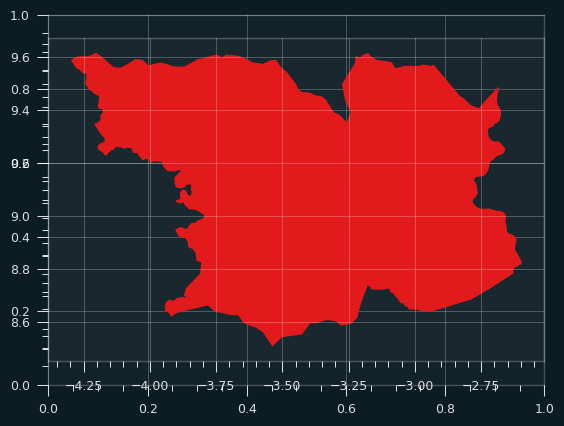

In [ ]:
polygones_bouna.plot()

### *Fusionner des geodataframe*

In [ ]:
# Exemple 2 : Récupérer les limites administratives de plusieurs pays (senegal et mali ici)
countries_data = client.adm(["SEN", "mali","civ"], "ADM2")
list_gdf=[gdf for key, gdf in countries_data.items()] # Liste de dataframes
countries_merged_data=fusion(list_gdf) # Fusion des dataframes
countries_merged_data.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-11.88782 13.38481, -11.88765 13.391...",Bakel,,50182788B16013842146029,SEN,ADM2
1,"POLYGON ((-16.38592 15.02258, -16.40452 15.023...",Bambey,,50182788B75300917140294,SEN,ADM2
2,"POLYGON ((-15.9775 12.88596, -15.97446 12.8904...",Bignona,,50182788B19391387689457,SEN,ADM2
3,"POLYGON ((-15.59024 13.8291, -15.58246 13.8437...",Birkelane,,50182788B56779252201559,SEN,ADM2
4,"POLYGON ((-15.9775 12.88596, -15.97 12.89171, ...",Bounkiling,,50182788B68388966372963,SEN,ADM2


### *Creer une nouvelle colonne*

In [ ]:
new_countries_data=add_column(df=countries_merged_data,column_name="random_data",expression="random.randint(1,100)",globals_dict={"random":random})
# global_dics correspond a la liste des packages necessaires pour evaluer l'expression
new_countries_data.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,random_data
0,"POLYGON ((-11.88782 13.38481, -11.88765 13.391...",Bakel,,50182788B16013842146029,SEN,ADM2,49
1,"POLYGON ((-16.38592 15.02258, -16.40452 15.023...",Bambey,,50182788B75300917140294,SEN,ADM2,15
2,"POLYGON ((-15.9775 12.88596, -15.97446 12.8904...",Bignona,,50182788B19391387689457,SEN,ADM2,91
3,"POLYGON ((-15.59024 13.8291, -15.58246 13.8437...",Birkelane,,50182788B56779252201559,SEN,ADM2,63
4,"POLYGON ((-15.9775 12.88596, -15.97 12.89171, ...",Bounkiling,,50182788B68388966372963,SEN,ADM2,68


In [ ]:
new_countries_data=add_column(new_countries_data,"dataType","row['shapeGroup']+'-'+row['shapeType']")
# row dans l'expression correspont a une ligne de la dataframe
# shapeGroup et shapeType sont des colonnes de la dataframe
new_countries_data.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,random_data,dataType
0,"POLYGON ((-11.88782 13.38481, -11.88765 13.391...",Bakel,,50182788B16013842146029,SEN,ADM2,49,SEN-ADM2
1,"POLYGON ((-16.38592 15.02258, -16.40452 15.023...",Bambey,,50182788B75300917140294,SEN,ADM2,15,SEN-ADM2
2,"POLYGON ((-15.9775 12.88596, -15.97446 12.8904...",Bignona,,50182788B19391387689457,SEN,ADM2,91,SEN-ADM2
3,"POLYGON ((-15.59024 13.8291, -15.58246 13.8437...",Birkelane,,50182788B56779252201559,SEN,ADM2,63,SEN-ADM2
4,"POLYGON ((-15.9775 12.88596, -15.97 12.89171, ...",Bounkiling,,50182788B68388966372963,SEN,ADM2,68,SEN-ADM2


In [ ]:
list(new_countries_data.columns)

['geometry',
 'shapeName',
 'shapeISO',
 'shapeID',
 'shapeGroup',
 'shapeType',
 'random_data',
 'dataType']

### *Creer un geodataframe de centroïde*

In [ ]:

coundtries_centroids = centroids(new_countries_data)

# Maintenant coundtries_centroids est un GeoDataFrame de points (centroïdes)
# avec tous les attributs originaux de new_countries_data

coundtries_centroids.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,random_data,dataType
0,POINT (-12.25523 14.17004),Bakel,,50182788B16013842146029,SEN,ADM2,49,SEN-ADM2
1,POINT (-16.48386 14.80261),Bambey,,50182788B75300917140294,SEN,ADM2,15,SEN-ADM2
2,POINT (-16.36673 12.88758),Bignona,,50182788B19391387689457,SEN,ADM2,91,SEN-ADM2
3,POINT (-15.68446 14.05259),Birkelane,,50182788B56779252201559,SEN,ADM2,63,SEN-ADM2
4,POINT (-15.60351 13.13488),Bounkiling,,50182788B68388966372963,SEN,ADM2,68,SEN-ADM2


<Axes: >

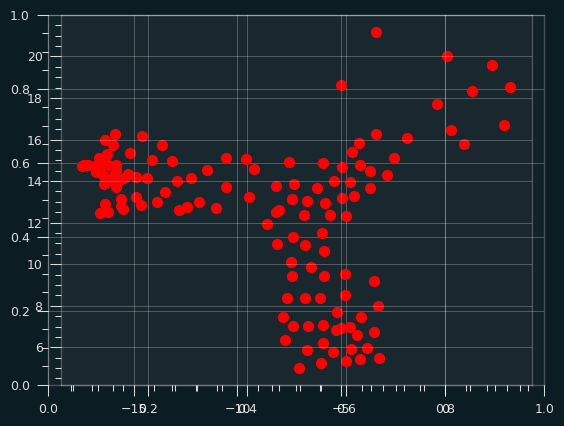

In [ ]:

# Visualisation simple avec matplotlib

coundtries_centroids.plot(markersize=50, color='red',label="Centroïde")

## **Visualisation de données**

cartograpy permet de creer rapidement des cartes pour visualier les données géographiques.

In [ ]:
from cartograpy.mapper import *

In [ ]:
# J'ajoute des données aléatoires pour la visualisation
import random
civ_data['data'] = [random.randint(0,10000) for i in range(len(civ_data))]

In [ ]:
civ_data.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,data
0,"POLYGON ((-4.68451 6.27179, -4.6868 6.26883, -...",Agneby-Tiassa,,98640826B52449815511854,CIV,ADM2,4588
1,"POLYGON ((-7.71925 9.07004, -7.72574 9.06397, ...",Bafing,,98640826B37750272367318,CIV,ADM2,8666
2,"POLYGON ((-6.19702 10.24246, -6.20038 10.24495...",Bagoue,,98640826B26044148659027,CIV,ADM2,8911
3,"MULTIPOLYGON (((-4.68451 6.27179, -4.68338 6.2...",Belier,,98640826B5123145245776,CIV,ADM2,5065
4,"POLYGON ((-6.70042 9.06196, -6.70118 9.05639, ...",Bere,,98640826B43857880322183,CIV,ADM2,1436


In [ ]:
geocode_localite=results[0]
geocode_localite["data"]= [random.randint(0,10000) for i in range(len(geocode_localite))]
geocode_localite.head()

,query,address,latitude,longitude,altitude,raw,geometry,data
0,Abidjan,"Abidjan, Côte d’Ivoire",5.320357,-4.016107,0.0,"{'place_id': 275432765, 'licence': 'Data © Ope...",POINT (-4.01611 5.32036),464
1,Yamoussoukro,"Yamoussoukro, Côte d’Ivoire",6.820007,-5.277603,0.0,"{'place_id': 405167260, 'licence': 'Data © Ope...",POINT (-5.2776 6.82001),3340
2,Bouaké,"Bouaké, Gbêkê, Vallée du Bandama, Côte d’Ivoire",7.689021,-5.028355,0.0,"{'place_id': 277030935, 'licence': 'Data © Ope...",POINT (-5.02836 7.68902),778
3,Korhogo,"Korhogo, Poro, Savanes, Côte d’Ivoire",9.458070,-5.631629,0.0,"{'place_id': 275218468, 'licence': 'Data © Ope...",POINT (-5.63163 9.45807),8609
4,Man CI,"Man, Tonkpi, Montagnes, Côte d’Ivoire",7.410258,-7.550372,0.0,"{'place_id': 275770928, 'licence': 'Data © Ope...",POINT (-7.55037 7.41026),3219


### *Voir la liste des palletes de couleurs diponible*

In [ ]:
# Les groupes de palettes diponibles
get_available_palettes().keys()

dict_keys(['custom', 'seaborn_qualitative', 'seaborn_sequential', 'seaborn_diverging', 'matplotlib_sequential', 'matplotlib_diverging', 'matplotlib_cyclic', 'matplotlib_qualitative'])

In [ ]:
# Voir les pallettes disponibles dans un groupe
get_available_palettes()["seaborn_sequential"]

['Blues',
 'BuGn',
 'BuPu',
 'GnBu',
 'Greens',
 'Greys',
 'Oranges',
 'OrRd',
 'PuBu',
 'PuBuGn',
 'PuRd',
 'Purples',
 'RdPu',
 'Reds',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'rocket',
 'mako',
 'flare',
 'crest']

### *Voir la liste des polices d'écritures disponibles*

In [ ]:
get_fonts()[0:10] # Pour voir les 10 prémières polices 

['Agency FB',
 'Algerian',
 'Arial',
 'Arial Rounded MT Bold',
 'Bahnschrift',
 'Baskerville Old Face',
 'Bauhaus 93',
 'Bell MT',
 'Berlin Sans FB',
 'Berlin Sans FB Demi']

In [ ]:
# Pour filtrer par un mot clé
get_fonts("time")[0]

'Times New Roman'

### *Visualiser des données vectorielles*
**Creer une carte cloropleth simple**

In [ ]:
# Map().get_north_arrows()

In [ ]:
# import matplotx
# print(matplotx.styles.duftify(matplotx.styles.dracula))
# plt.style.use(matplotx.styles.duftify(matplotx.styles.dracula))

📄 Format de papier: B3 (landscape) - Dimensions: 353 x 500 mm - Figure: 19.7" x 13.9"


Can't handle color: param(outline)


📊 Centrage intelligent appliqué:
   Format: B3 (landscape)
   Ratio figure: 1.42
   Ratio données: 0.95
   Étendue: [-10.69, -0.38, 3.91, 11.19]
📊 Centrage intelligent appliqué:
   Format: B3 (landscape)
   Ratio figure: 1.42
   Ratio données: 0.95
   Étendue: [-10.69, -0.38, 3.91, 11.19]
{'fontsize': 9, 'frameon': False, 'fancybox': False, 'shadow': False, 'framealpha': 1.0, 'handlelength': 1.5, 'handletextpad': 0.5}
🛑Element de légende ajouté None
⚠️  Aucun élément de légende disponible
🎨 Préréglage 'minimal' appliqué à la légende


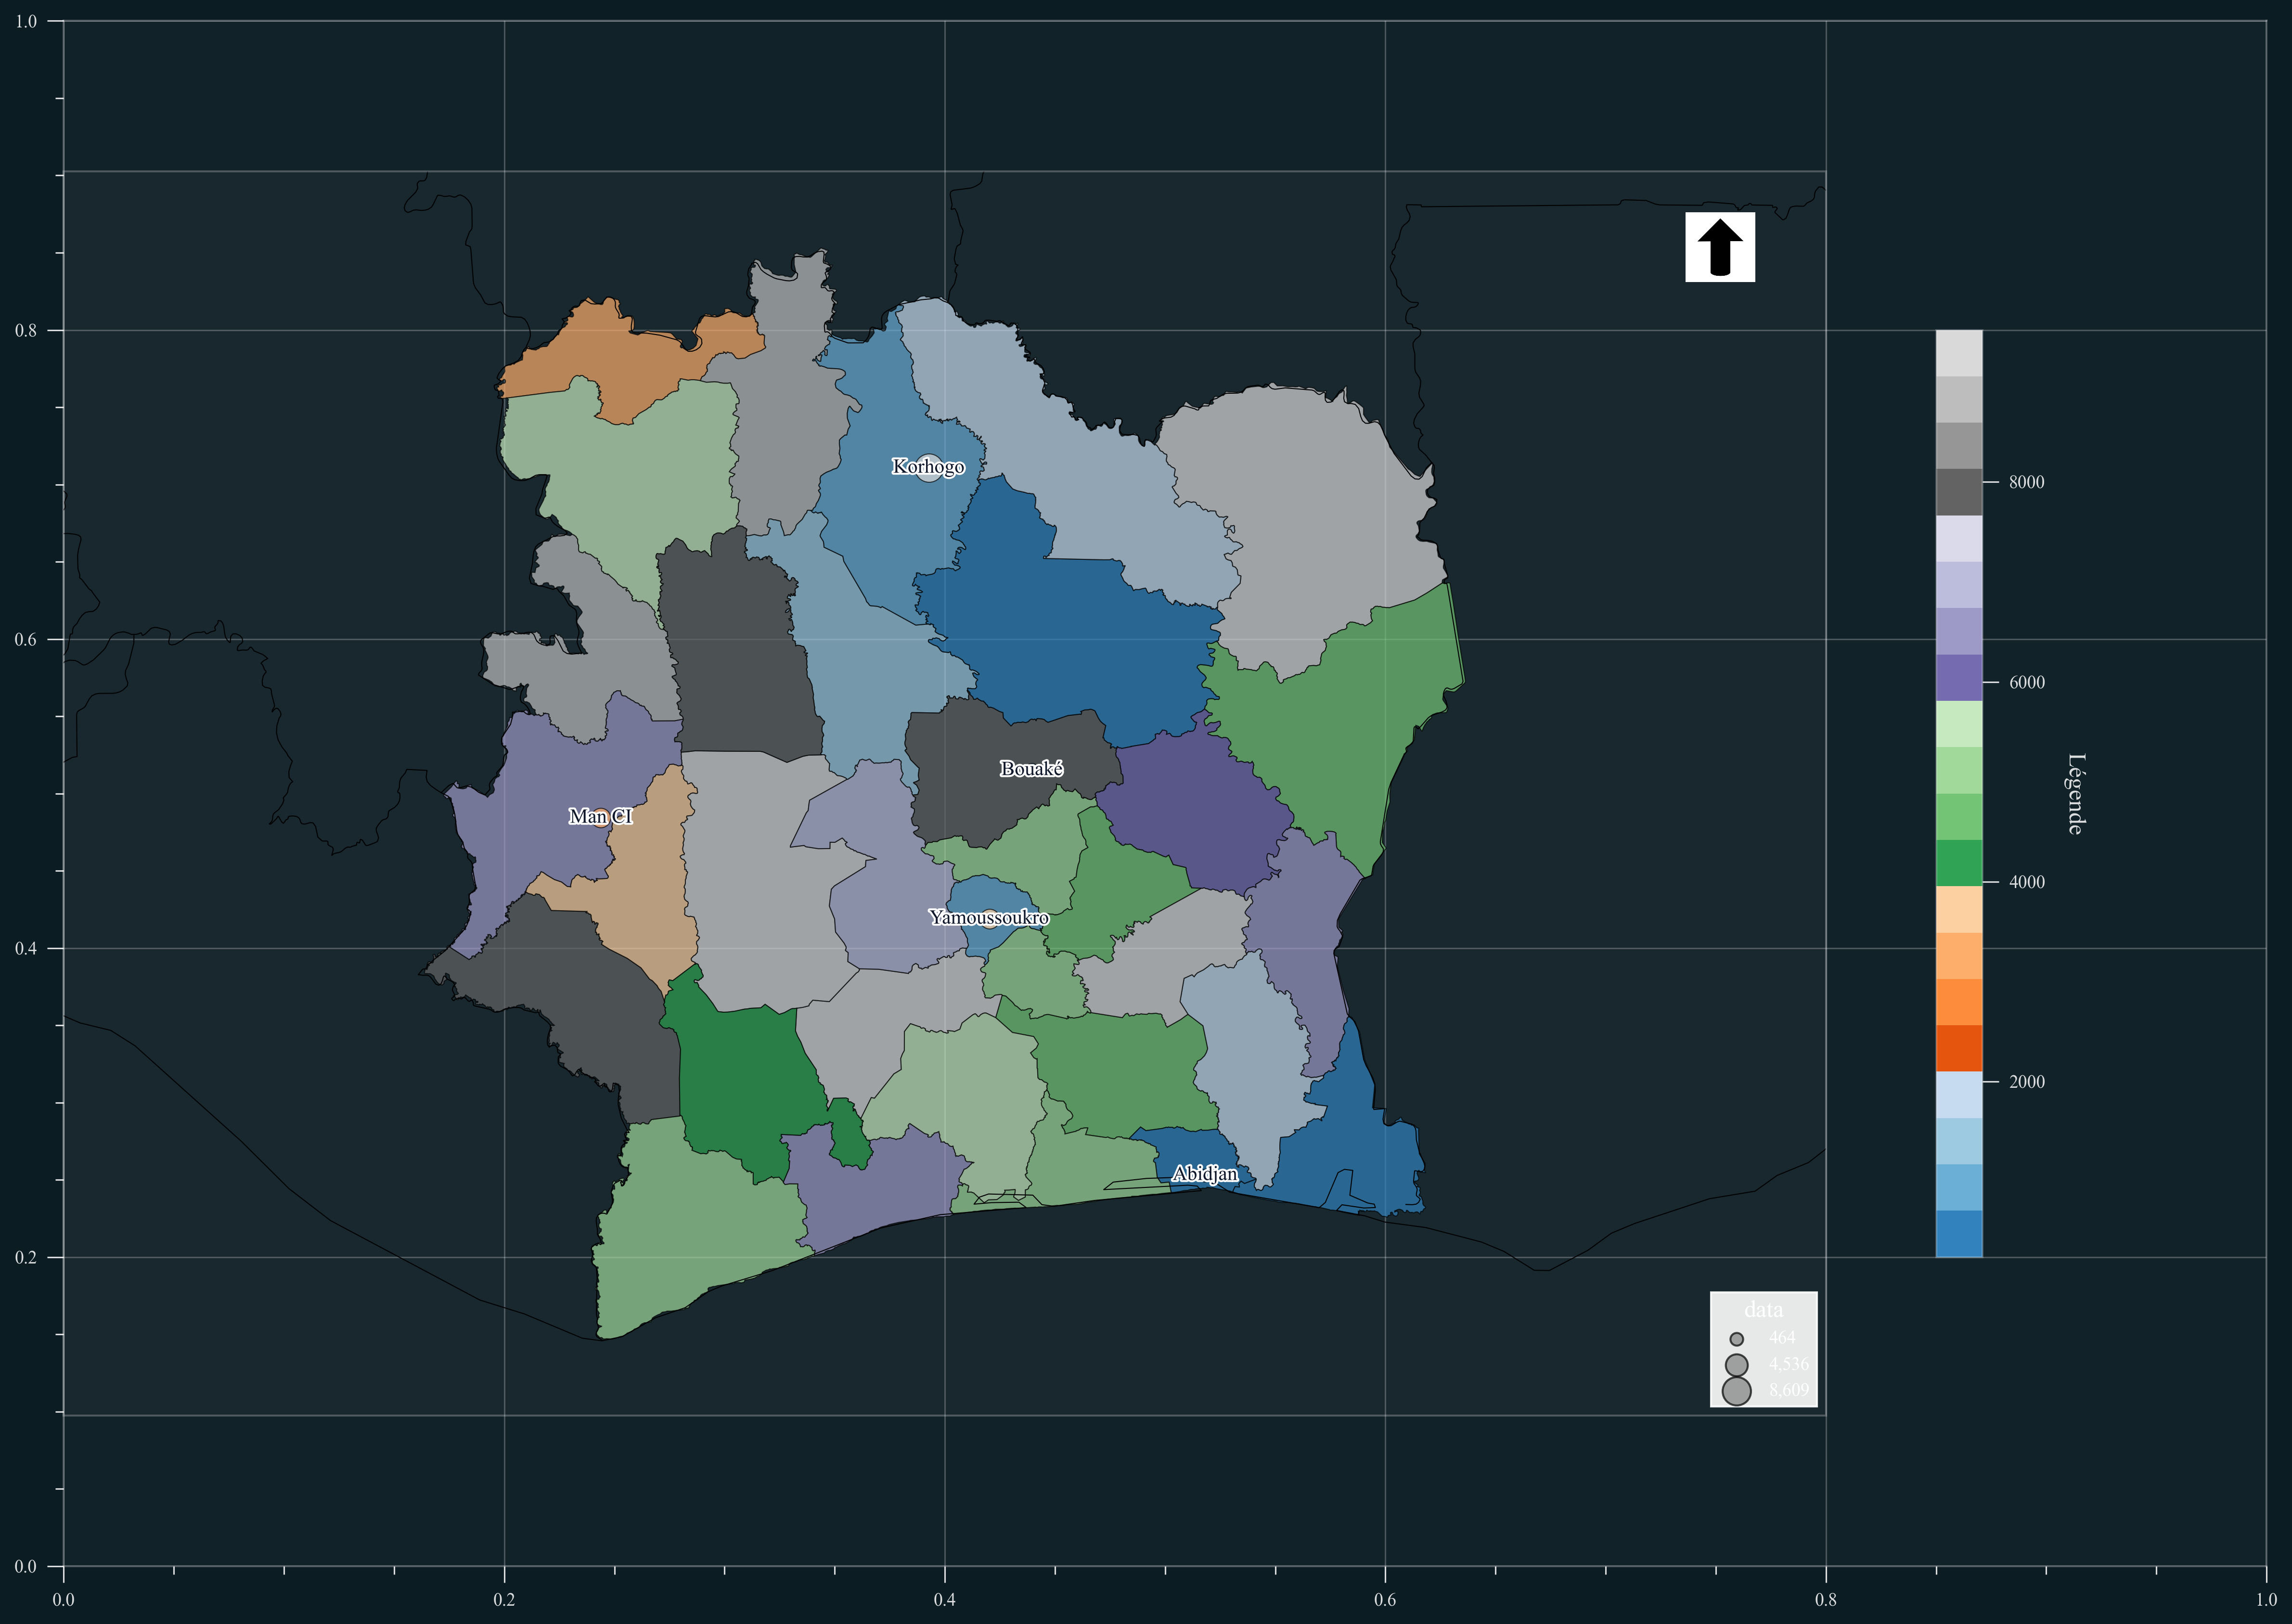

In [ ]:
carte_ci=Map(figsize="B3", projection=ccrs.PlateCarree(),title="")
# carte_ci.set_title("Carte de la Côte d'Ivoire", fontsize=22, fontweight="bold",font_name="Bahnschrift")
carte_ci.add_polygons_cloropleth(gdf=civ_data,
                              column_to_plot='data',
                                title='Légende',
                                cmap='tab20c',
                                )
carte_ci.add_points_cloropleth(
    gdf=geocode_localite,
    column_to_plot="data",
    label_column="query",
    point_size_column="data",
    show_colorbar=False,
    cmap="tab20c"
    
)
# carte_ci.add_gridlines()
font_name=get_fonts("time")[0]
font_name
carte_ci.set_font(font_name, size=12)
carte_ci.add_arrow(1, position=(-1.0,10.75),zoom=0.06, color="black")
carte_ci.figsize=(18,18)
carte_ci.legend_presets("minimal")


### *Visualiser des données rasters*

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kanic\AppData\Local\Temp\ipykernel_14004\2453623371.py:5: SyntaxWarning: invalid escape sequence '\d'
  carte_dem.add_raster('..\data\other\Limite DEM Bouna.tif', cmap='tab20c', title='Élévation (m)')
Can't handle color: param(outline)
Can't handle color: param(outline)


Location est : (0.1, 0.05). La bare d'échelle est placé à 10.0 % de la longeur et à 5.0 % de la hauteur)


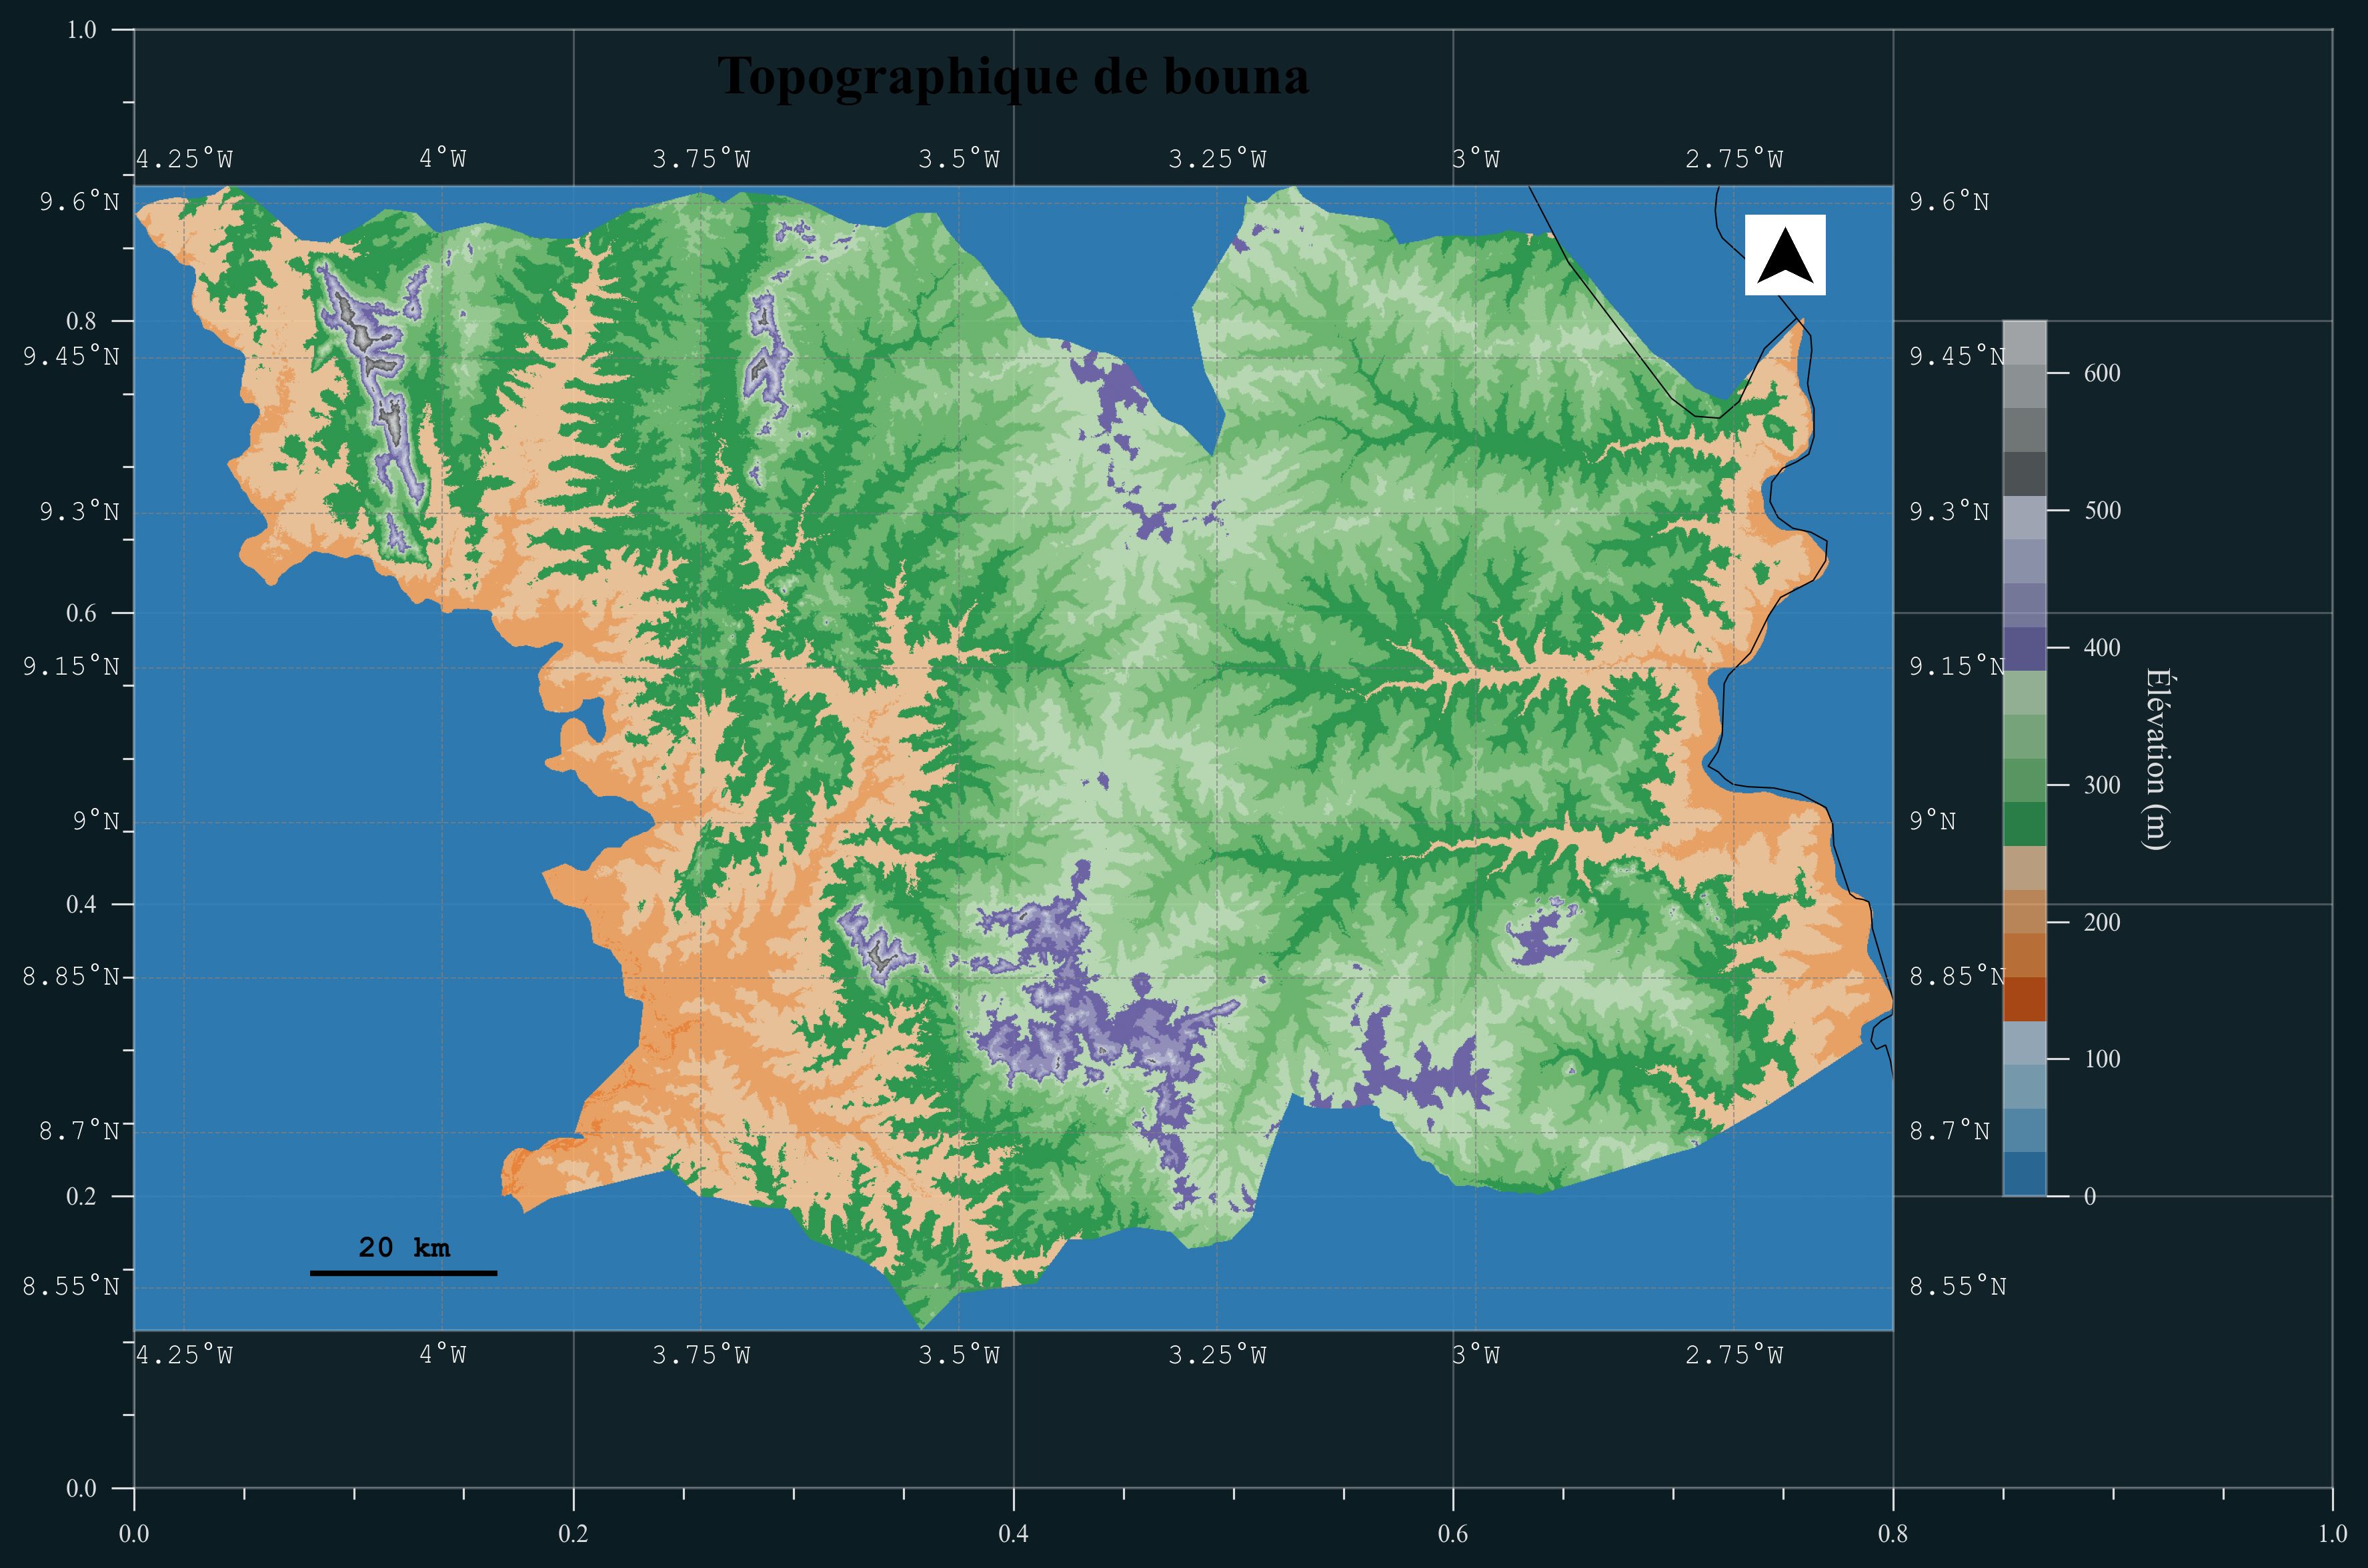

In [ ]:
# Création d'une carte raster
carte_dem = Map(figsize=(12, 8), projection=ccrs.PlateCarree())

# Ajout d'une couche raster
carte_dem.add_raster('..\data\other\Limite DEM Bouna.tif', cmap='tab20c', title='Élévation (m)')

font_name=get_fonts("couri")[0]

carte_dem.set_font(font_name, size=12)
carte_dem.set_title('Topographique de bouna', fontsize=20, color='Black', pad=20)
carte_dem.add_arrow(3, position=(-2.70, 9.55), zoom=0.05, color='black')
carte_dem.add_gridlines()
carte_dem.add_scale_bar(length=20, units="km",pad=0.01)
carte_dem.show()


# Sauvegarde
# carte.save('carte_demo.png')

In [ ]:
civ_data.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,data
0,"POLYGON ((-4.68451 6.27179, -4.6868 6.26883, -...",Agneby-Tiassa,,98640826B52449815511854,CIV,ADM2,4588
1,"POLYGON ((-7.71925 9.07004, -7.72574 9.06397, ...",Bafing,,98640826B37750272367318,CIV,ADM2,8666
2,"POLYGON ((-6.19702 10.24246, -6.20038 10.24495...",Bagoue,,98640826B26044148659027,CIV,ADM2,8911
3,"MULTIPOLYGON (((-4.68451 6.27179, -4.68338 6.2...",Belier,,98640826B5123145245776,CIV,ADM2,5065
4,"POLYGON ((-6.70042 9.06196, -6.70118 9.05639, ...",Bere,,98640826B43857880322183,CIV,ADM2,1436


In [ ]:
list(civ_data.shapeName.unique())[0:10]

['Agneby-Tiassa',
 'Bafing',
 'Bagoue',
 'Belier',
 'Bere',
 'Bounkani',
 'Cavally',
 "District Autonome D'Abidjan",
 'District Autonome De Yamoussoukro',
 'Folon']

In [ ]:
civ_data["shapeName"].replace({
    "District Autonome D'Abidjan": "Abidjan",
    "District Autonome De Yamoussoukro": "Yamoussoukro"
}, inplace=True)

C:\Users\kanic\AppData\Local\Temp\ipykernel_14004\1025282276.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  civ_data["shapeName"].replace({


In [ ]:
geocode_localite.head()

,query,address,latitude,longitude,altitude,raw,geometry,data
0,Abidjan,"Abidjan, Côte d’Ivoire",5.320357,-4.016107,0.0,"{'place_id': 275432765, 'licence': 'Data © Ope...",POINT (-4.01611 5.32036),464
1,Yamoussoukro,"Yamoussoukro, Côte d’Ivoire",6.820007,-5.277603,0.0,"{'place_id': 405167260, 'licence': 'Data © Ope...",POINT (-5.2776 6.82001),3340
2,Bouaké,"Bouaké, Gbêkê, Vallée du Bandama, Côte d’Ivoire",7.689021,-5.028355,0.0,"{'place_id': 277030935, 'licence': 'Data © Ope...",POINT (-5.02836 7.68902),778
3,Korhogo,"Korhogo, Poro, Savanes, Côte d’Ivoire",9.458070,-5.631629,0.0,"{'place_id': 275218468, 'licence': 'Data © Ope...",POINT (-5.63163 9.45807),8609
4,Man CI,"Man, Tonkpi, Montagnes, Côte d’Ivoire",7.410258,-7.550372,0.0,"{'place_id': 275770928, 'licence': 'Data © Ope...",POINT (-7.55037 7.41026),3219


In [ ]:
font=get_fonts("time")[0]
font

'Times New Roman'

In [ ]:
signfont=get_fonts("scri")[2]
signfont

'Freestyle Script'

In [ ]:
from cartograpy.processing import *

geocode_localite=add_column(geocode_localite,"pointsize",expression="row.data/60")

In [ ]:
geocode_localite.head()

,query,address,latitude,longitude,altitude,raw,geometry,data,pointsize
0,Abidjan,"Abidjan, Côte d’Ivoire",5.320357,-4.016107,0.0,"{'place_id': 275432765, 'licence': 'Data © Ope...",POINT (-4.01611 5.32036),464,7.733333
1,Yamoussoukro,"Yamoussoukro, Côte d’Ivoire",6.820007,-5.277603,0.0,"{'place_id': 405167260, 'licence': 'Data © Ope...",POINT (-5.2776 6.82001),3340,55.666667
2,Bouaké,"Bouaké, Gbêkê, Vallée du Bandama, Côte d’Ivoire",7.689021,-5.028355,0.0,"{'place_id': 277030935, 'licence': 'Data © Ope...",POINT (-5.02836 7.68902),778,12.966667
3,Korhogo,"Korhogo, Poro, Savanes, Côte d’Ivoire",9.458070,-5.631629,0.0,"{'place_id': 275218468, 'licence': 'Data © Ope...",POINT (-5.63163 9.45807),8609,143.483333
4,Man CI,"Man, Tonkpi, Montagnes, Côte d’Ivoire",7.410258,-7.550372,0.0,"{'place_id': 275770928, 'licence': 'Data © Ope...",POINT (-7.55037 7.41026),3219,53.650000


In [ ]:
from cartograpy.styling import *
list_all_styles()

{'matplotlib': ['Solarize_Light2',
  '_classic_test_patch',
  '_mpl-gallery',
  '_mpl-gallery-nogrid',
  'bmh',
  'bright',
  'cjk-jp-font',
  'cjk-kr-font',
  'cjk-sc-font',
  'cjk-tc-font',
  'classic',
  'cyberpunk',
  'dark_background',
  'fast',
  'fivethirtyeight',
  'ggplot',
  'grayscale',
  'grid',
  'high-contrast',
  'high-vis',
  'ieee',
  'latex-sans',
  'light',
  'muted',
  'nature',
  'no-latex',
  'notebook',
  'petroff10',
  'pgf',
  'retro',
  'russian-font',
  'sans',
  'scatter',
  'science',
  'seaborn-v0_8',
  'seaborn-v0_8-bright',
  'seaborn-v0_8-colorblind',
  'seaborn-v0_8-dark',
  'seaborn-v0_8-dark-palette',
  'seaborn-v0_8-darkgrid',
  'seaborn-v0_8-deep',
  'seaborn-v0_8-muted',
  'seaborn-v0_8-notebook',
  'seaborn-v0_8-paper',
  'seaborn-v0_8-pastel',
  'seaborn-v0_8-poster',
  'seaborn-v0_8-talk',
  'seaborn-v0_8-ticks',
  'seaborn-v0_8-white',
  'seaborn-v0_8-whitegrid',
  'std-colors',
  'tableau-colorblind10',
  'turkish-font',
  'vibrant'],
 'seabo

### *Carte cloropleth*

📄 Format de papier: A4 (landscape) - Dimensions: 210 x 297 mm - Figure: 11.7" x 8.3"
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 0.91
   Étendue: [-9.82, -1.18, 4.50, 10.61]
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 0.91
   Étendue: [-9.82, -1.18, 4.50, 10.61]


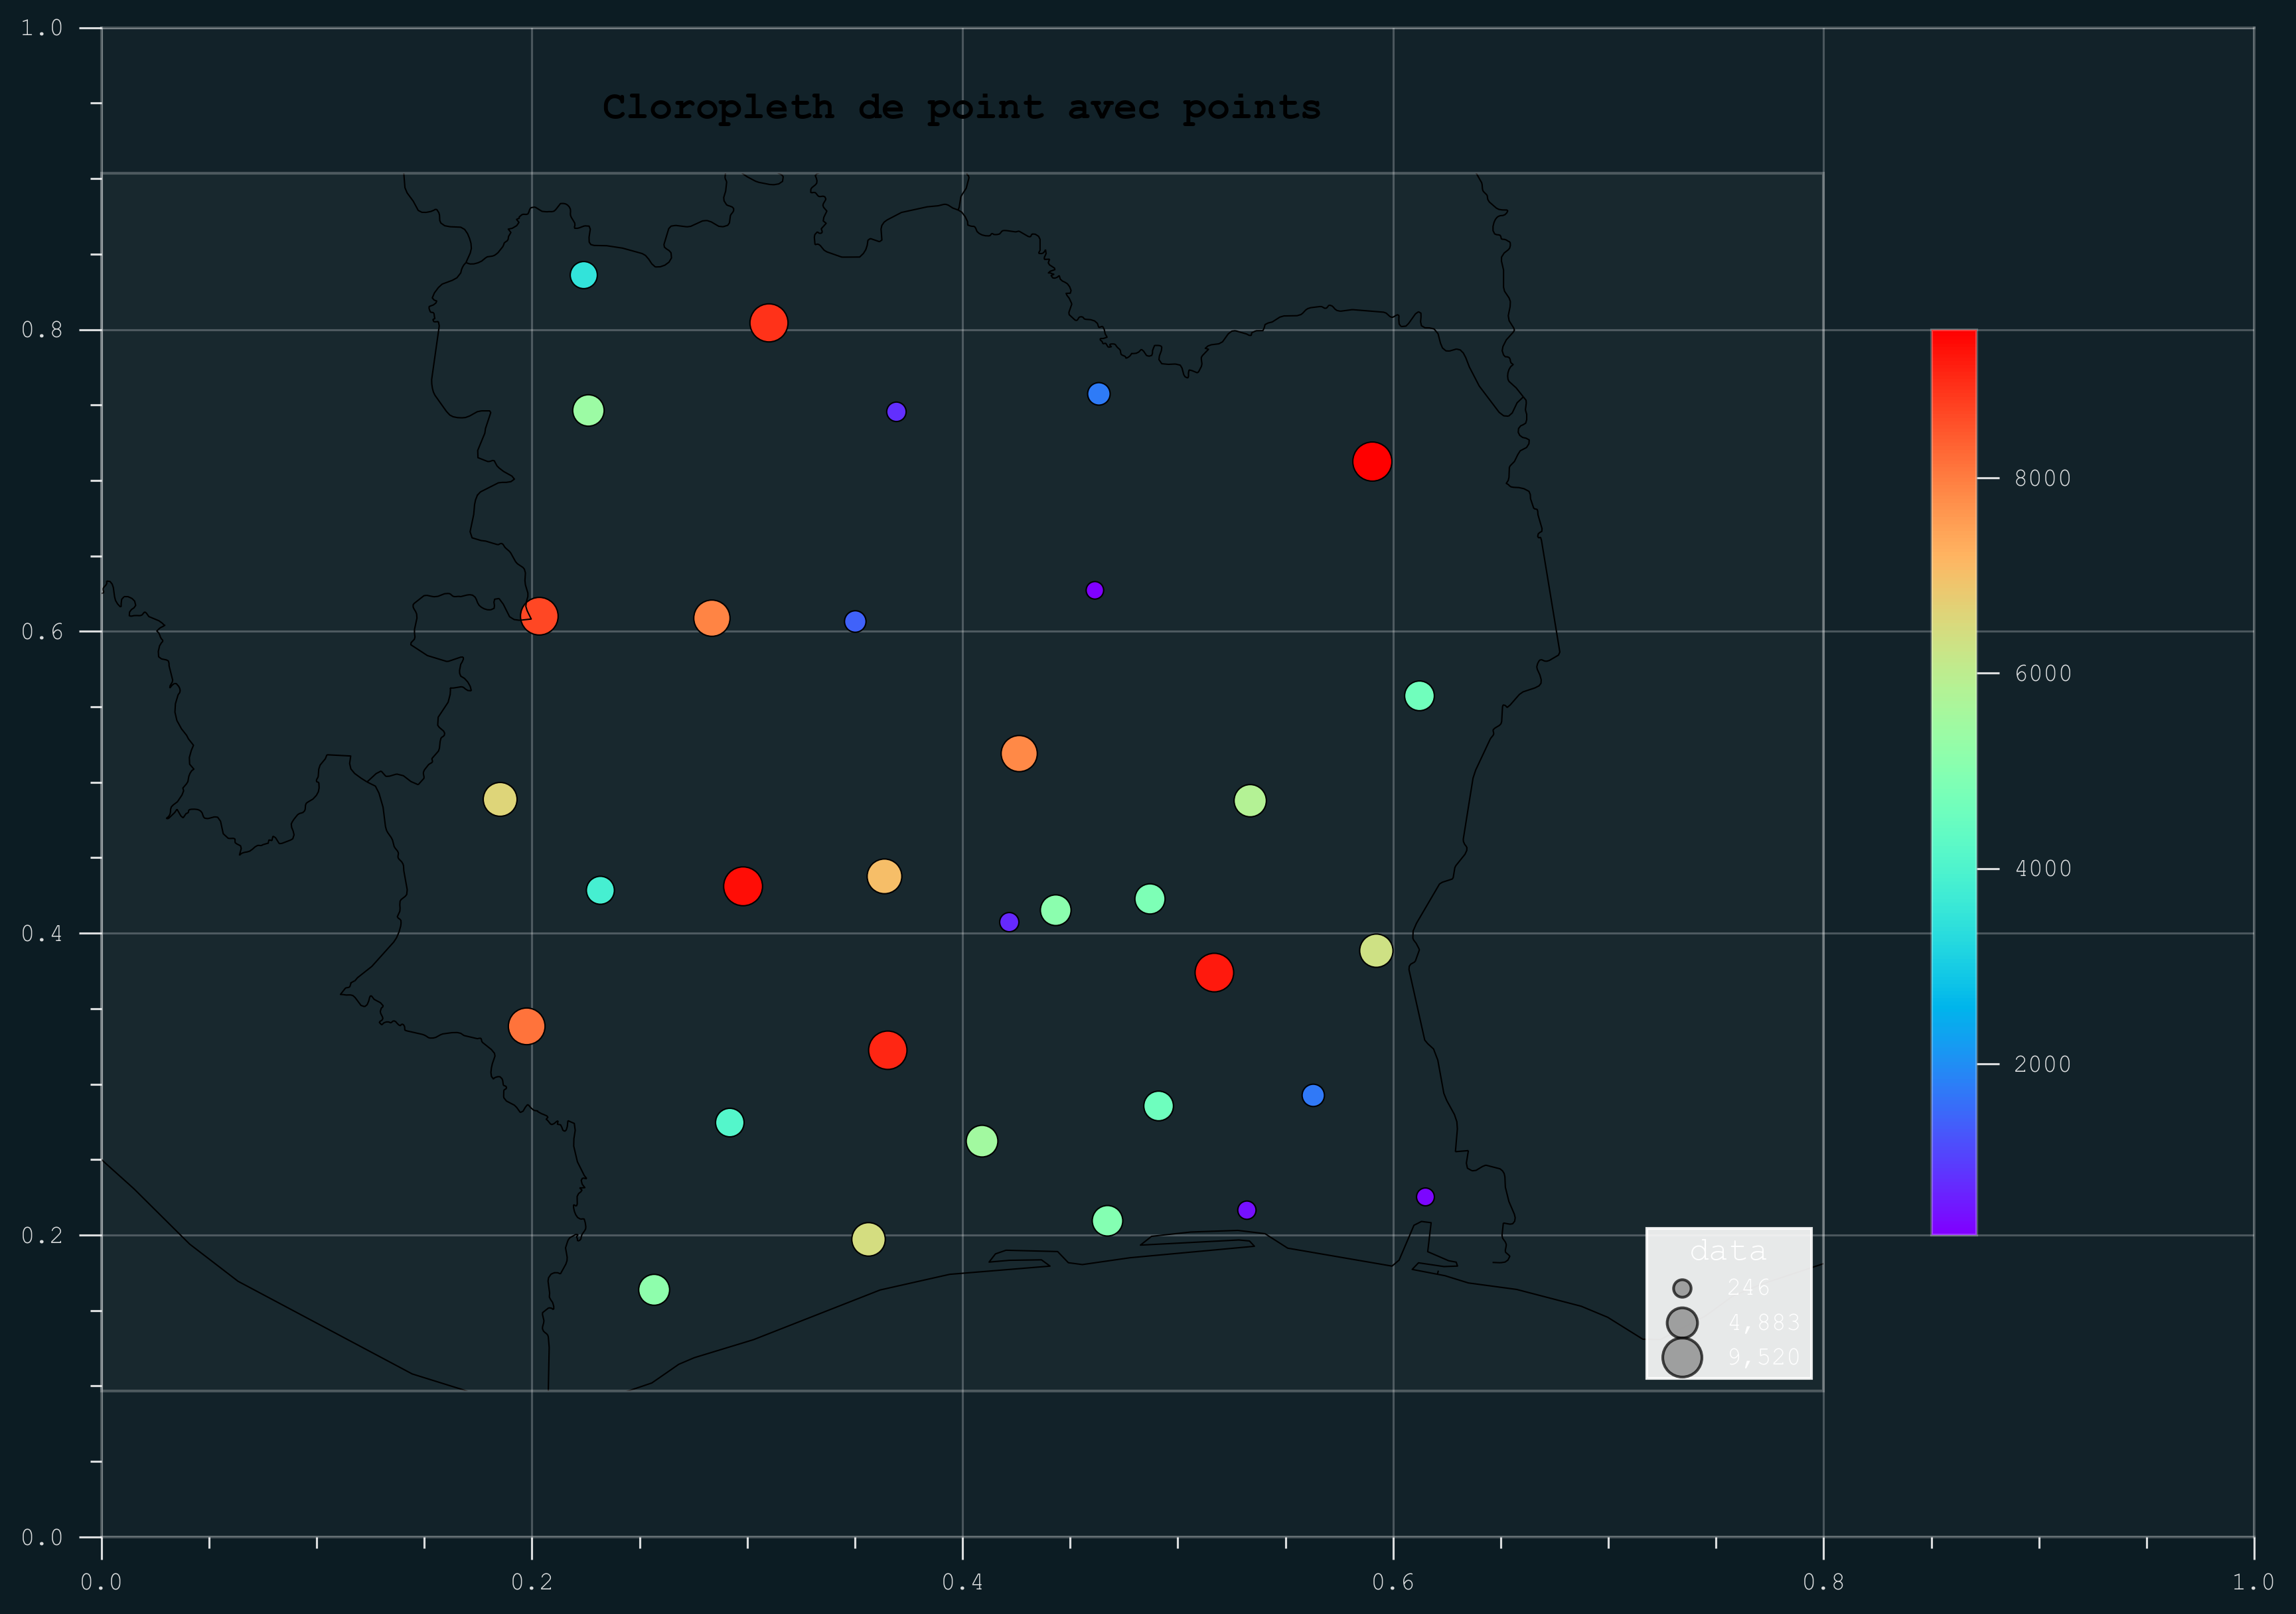

In [ ]:
# Creer un simple cloropleth de point
#============================================
carte2=Map(figsize="A4")
centroide=centroids(geodf=civ_data)
# civ_bound0=client.adm("civ","ADM0")
# carte2.add_polygons(civ_bound0)
carte2.add_points_cloropleth(gdf=centroide,column_to_plot="data",point_size_column="data",cmap="rainbow",alpha=1)
# carte2.add_gridlines()
carte2.set_title("Cloropleth de point avec points")
carte2.show()


In [ ]:
# Creer un cloropleth de polygone
#=================================================

# Creation de client geoboundaries
bound=data.GeoBoundaries()

# Téléchargement des données de découpage administrativve du mali et du sénégale
dic=bound.adm(["sen","mali"],adm="ADM2")

# Fusion des données du découpages administratif
data_sen_mali=fusion(dataframes_list=[dic["sen"],dic["mali"]])
data_sen_mali.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-11.88782 13.38481, -11.88765 13.391...",Bakel,,50182788B16013842146029,SEN,ADM2
1,"POLYGON ((-16.38592 15.02258, -16.40452 15.023...",Bambey,,50182788B75300917140294,SEN,ADM2
2,"POLYGON ((-15.9775 12.88596, -15.97446 12.8904...",Bignona,,50182788B19391387689457,SEN,ADM2
3,"POLYGON ((-15.59024 13.8291, -15.58246 13.8437...",Birkelane,,50182788B56779252201559,SEN,ADM2
4,"POLYGON ((-15.9775 12.88596, -15.97 12.89171, ...",Bounkiling,,50182788B68388966372963,SEN,ADM2


Vous pouvez utiliser explorer et manipuler **les palettes de couleurs** avec `colors` de cartograpy

In [ ]:
# Chargement de la bibliothèque
# from cartograpy import colors
# import pypalettes
# from pypalettes import load_cmap
# cmap=load_cmap("Coconut")

In [ ]:
# from pypalettes import show_cmap
# show_cmap("Coconut")

In [ ]:
# Création d'une colonne de données aléatoire

data_sen_mali=add_column(df=data_sen_mali,column_name="data",expression="random.randint(50,1000)",globals_dict={"random": random})

In [ ]:
data_sen_mali.head()



,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,data
0,"POLYGON ((-11.88782 13.38481, -11.88765 13.391...",Bakel,,50182788B16013842146029,SEN,ADM2,273
1,"POLYGON ((-16.38592 15.02258, -16.40452 15.023...",Bambey,,50182788B75300917140294,SEN,ADM2,135
2,"POLYGON ((-15.9775 12.88596, -15.97446 12.8904...",Bignona,,50182788B19391387689457,SEN,ADM2,810
3,"POLYGON ((-15.59024 13.8291, -15.58246 13.8437...",Birkelane,,50182788B56779252201559,SEN,ADM2,853
4,"POLYGON ((-15.9775 12.88596, -15.97 12.89171, ...",Bounkiling,,50182788B68388966372963,SEN,ADM2,149


📄 Format de papier: A4 (landscape) - Dimensions: 210 x 297 mm - Figure: 11.7" x 8.3"


Can't handle color: param(outline)


📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 1.47
   Étendue: [-19.27, 5.99, 8.64, 26.50]
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 1.47
   Étendue: [-19.27, 5.99, 8.64, 26.50]


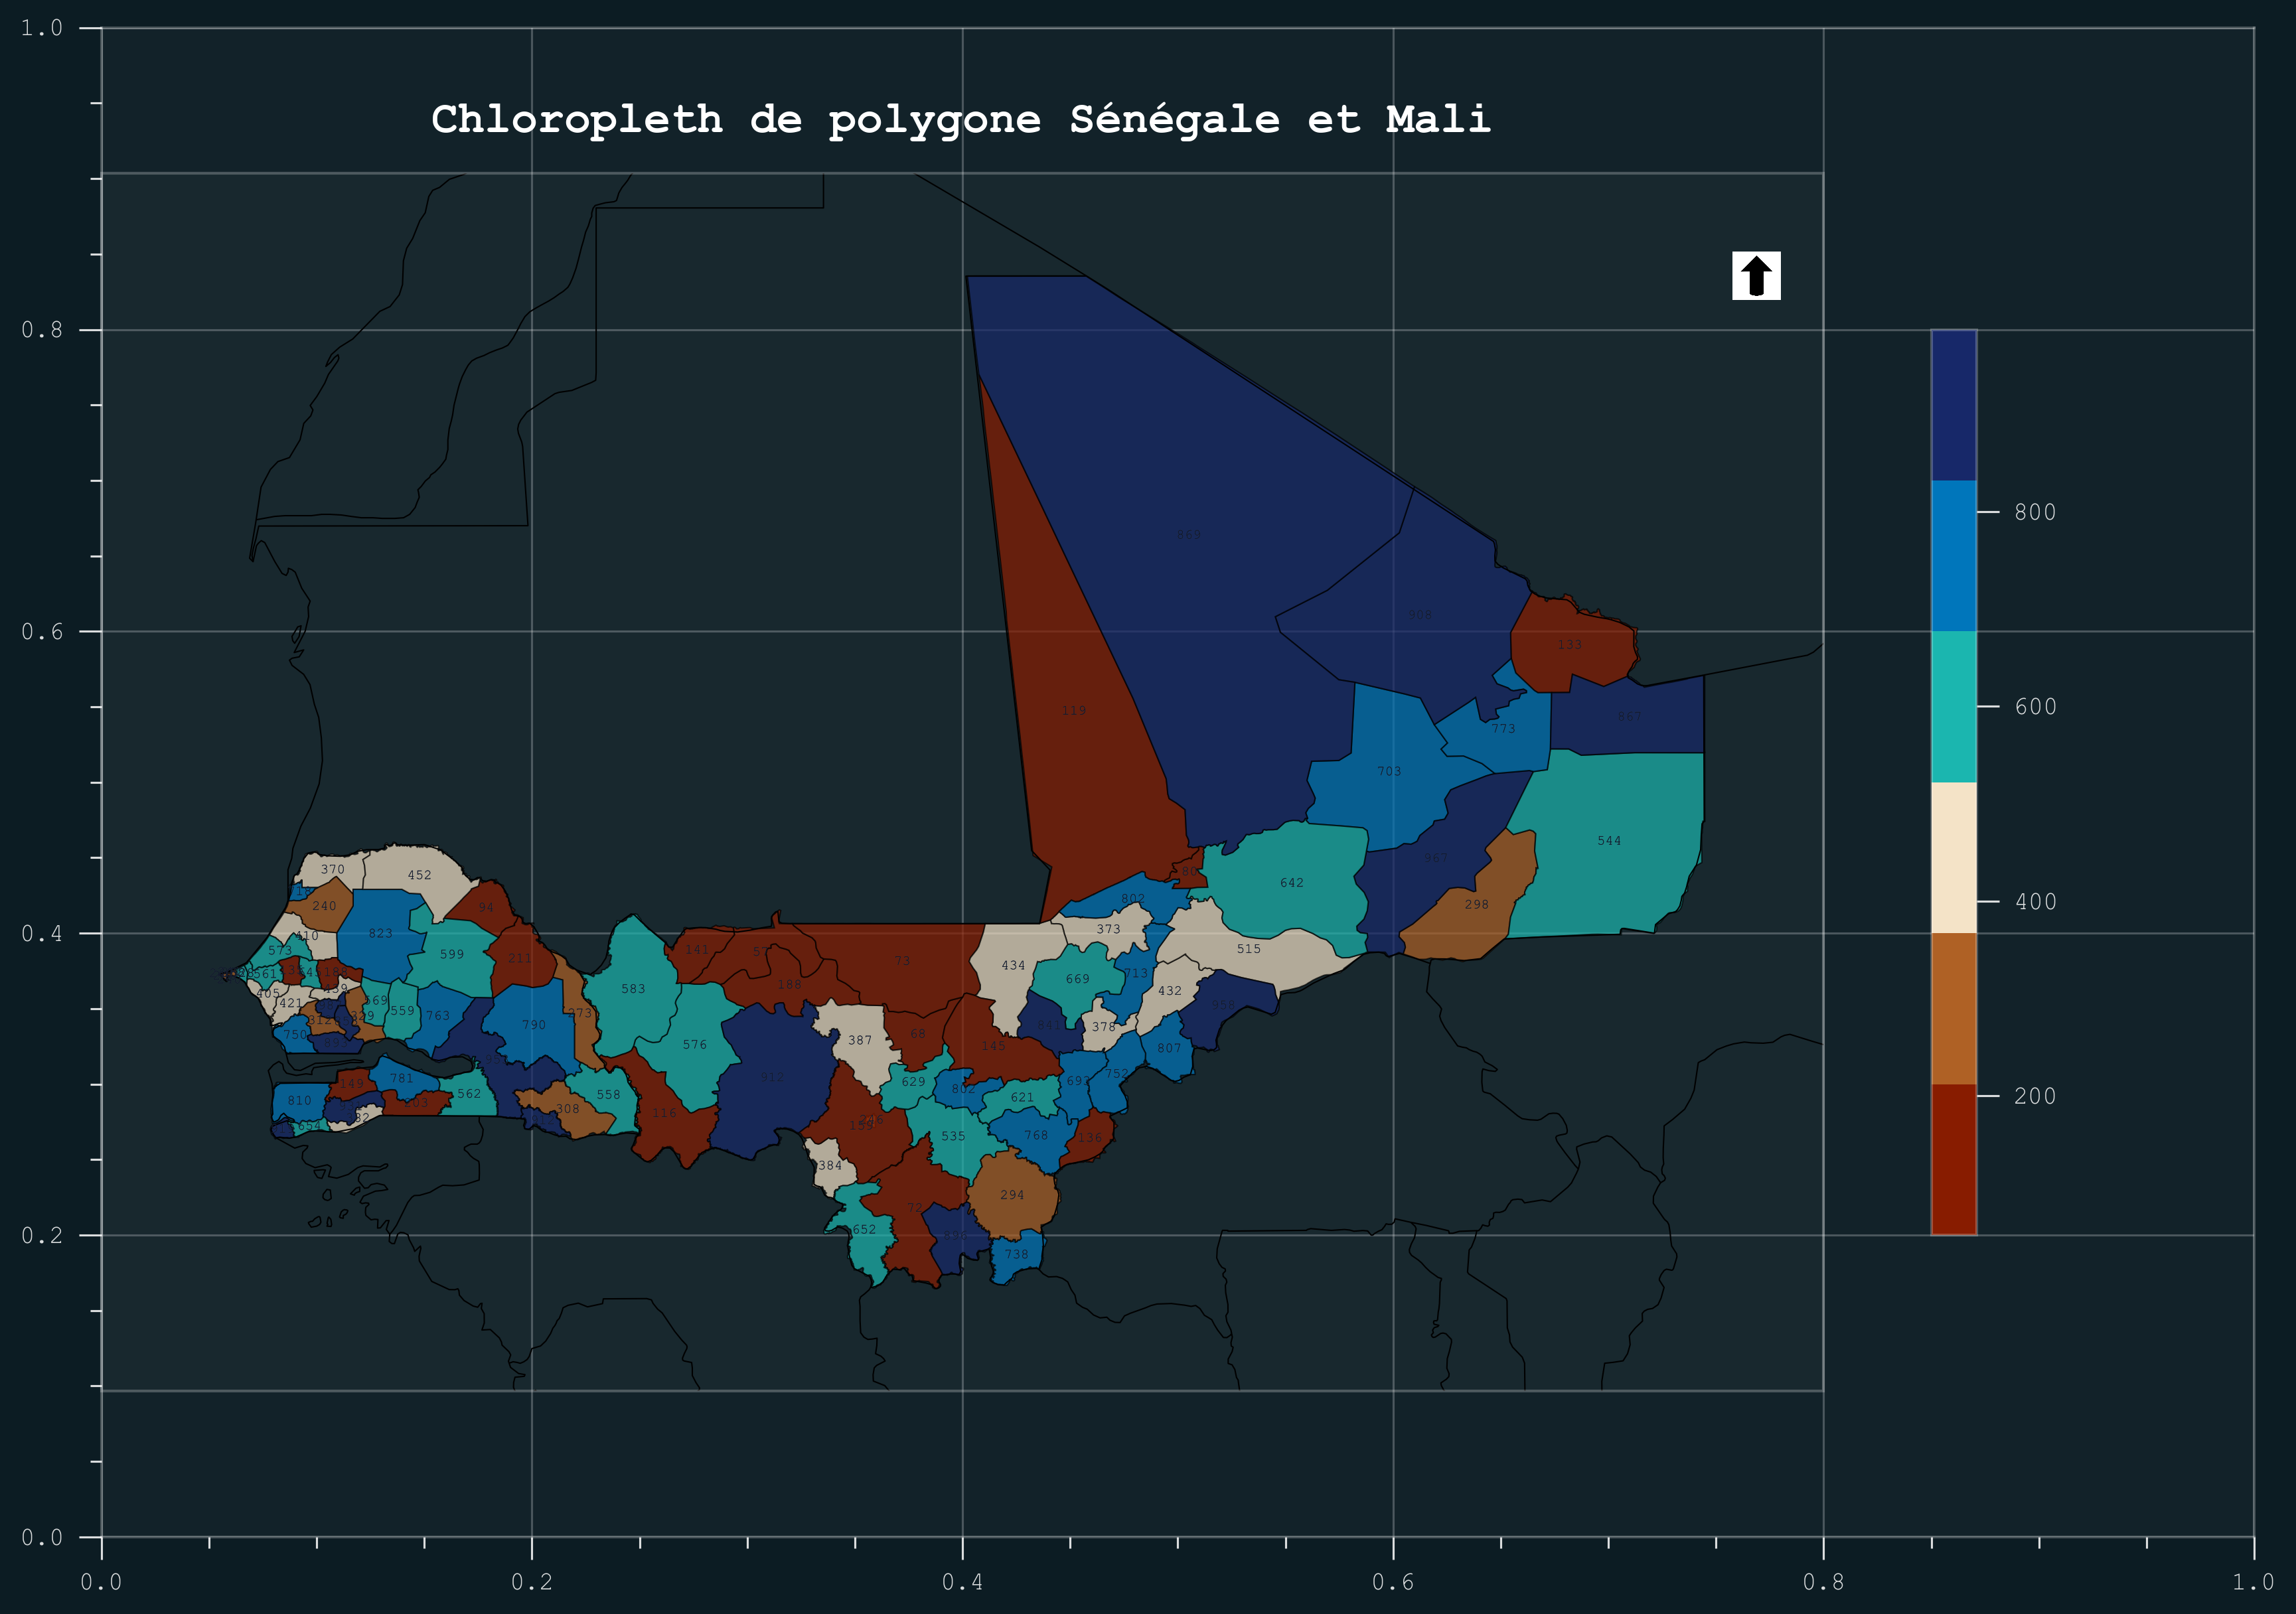

In [ ]:
# Création de carte cloropleth
carte3 = Map (figsize="A4",title="Chloropleth de polygone Sénégale et Mali")
carte3.add_polygons_cloropleth(gdf=data_sen_mali,column_to_plot="data",cmap="Coconut",)
carte3.add_labels(gdf=data_sen_mali,label_column="data",fontsize=5,outline_width=0.01)
# carte3.add_gridlines(fontsize=8)
carte3.add_arrow(1,position=(5,25),zoom=0.03)
# carte3.set_font(get_fonts("time")[0])
carte3.show()

### *Carte de ligne*

In [ ]:
# path="data\\QGIS-Training-Data\\exercise_data\shapefile\\rivers.shp"
# # data_riviere=load(path)
# carte4=Map(title="Carte de rivière")
# carte4.set_paper("A5")
# carte4.add_lines(data_riviere,color="blue",alpha=0.7,linewidth=1,linestyle="--")
# carte4.add_gridlines()
# carte4.add_arrow(5,position=(20.56,-33.32),zoom=0.03)
# carte4.add_scale_bar(15,units="km", pad=0.01,color="black",linewidth=3, location=(0.05,0.05))
# carte4.add_scale_bar(15,units="km", pad=0.01,color="red",linewidth=3, location=(0.15,0.05),label="")
# carte4.add_legend_element("line",color="blue",label="Rivière", linestyle="--", linewidth=1)
# carte4.legend_presets("minimal" ,loc="lower right")
# carte4.show()

### **Ajouter des couches de tous les types**

📄 Format de papier: A4 (landscape) - Dimensions: 210 x 297 mm - Figure: 11.7" x 8.3"
⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
['Polygon' 'MultiPolygon']
⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
['Point']
{'fontsize': 10, 'frameon': True, 'fancybox': True, 'shadow': True, 'framealpha': 0.9, 'facecolor': 'white', 'edgecolor': 'black', 'loc': 'lower right'}
🛑Element de légende ajouté None
✅ Légende personnalisée créée avec 2 éléments
🎨 Préréglage 'default' appliqué à la légende
📄 Format mis à jour: A4 (portrait) - Dimensions: 210 x 297 mm - Figure: 8.3" x 11.7"
📊 Centrage intelligent appliqué:
   Format: A4 (portrait)
   Ratio figure: 0.71
   Ratio données: 1.47
   Étendue: [-19.71, 6.42, -0.91, 36.05]
🛑Element de légende ajouté None
✅ Légende personnalisée créée avec 2 éléments


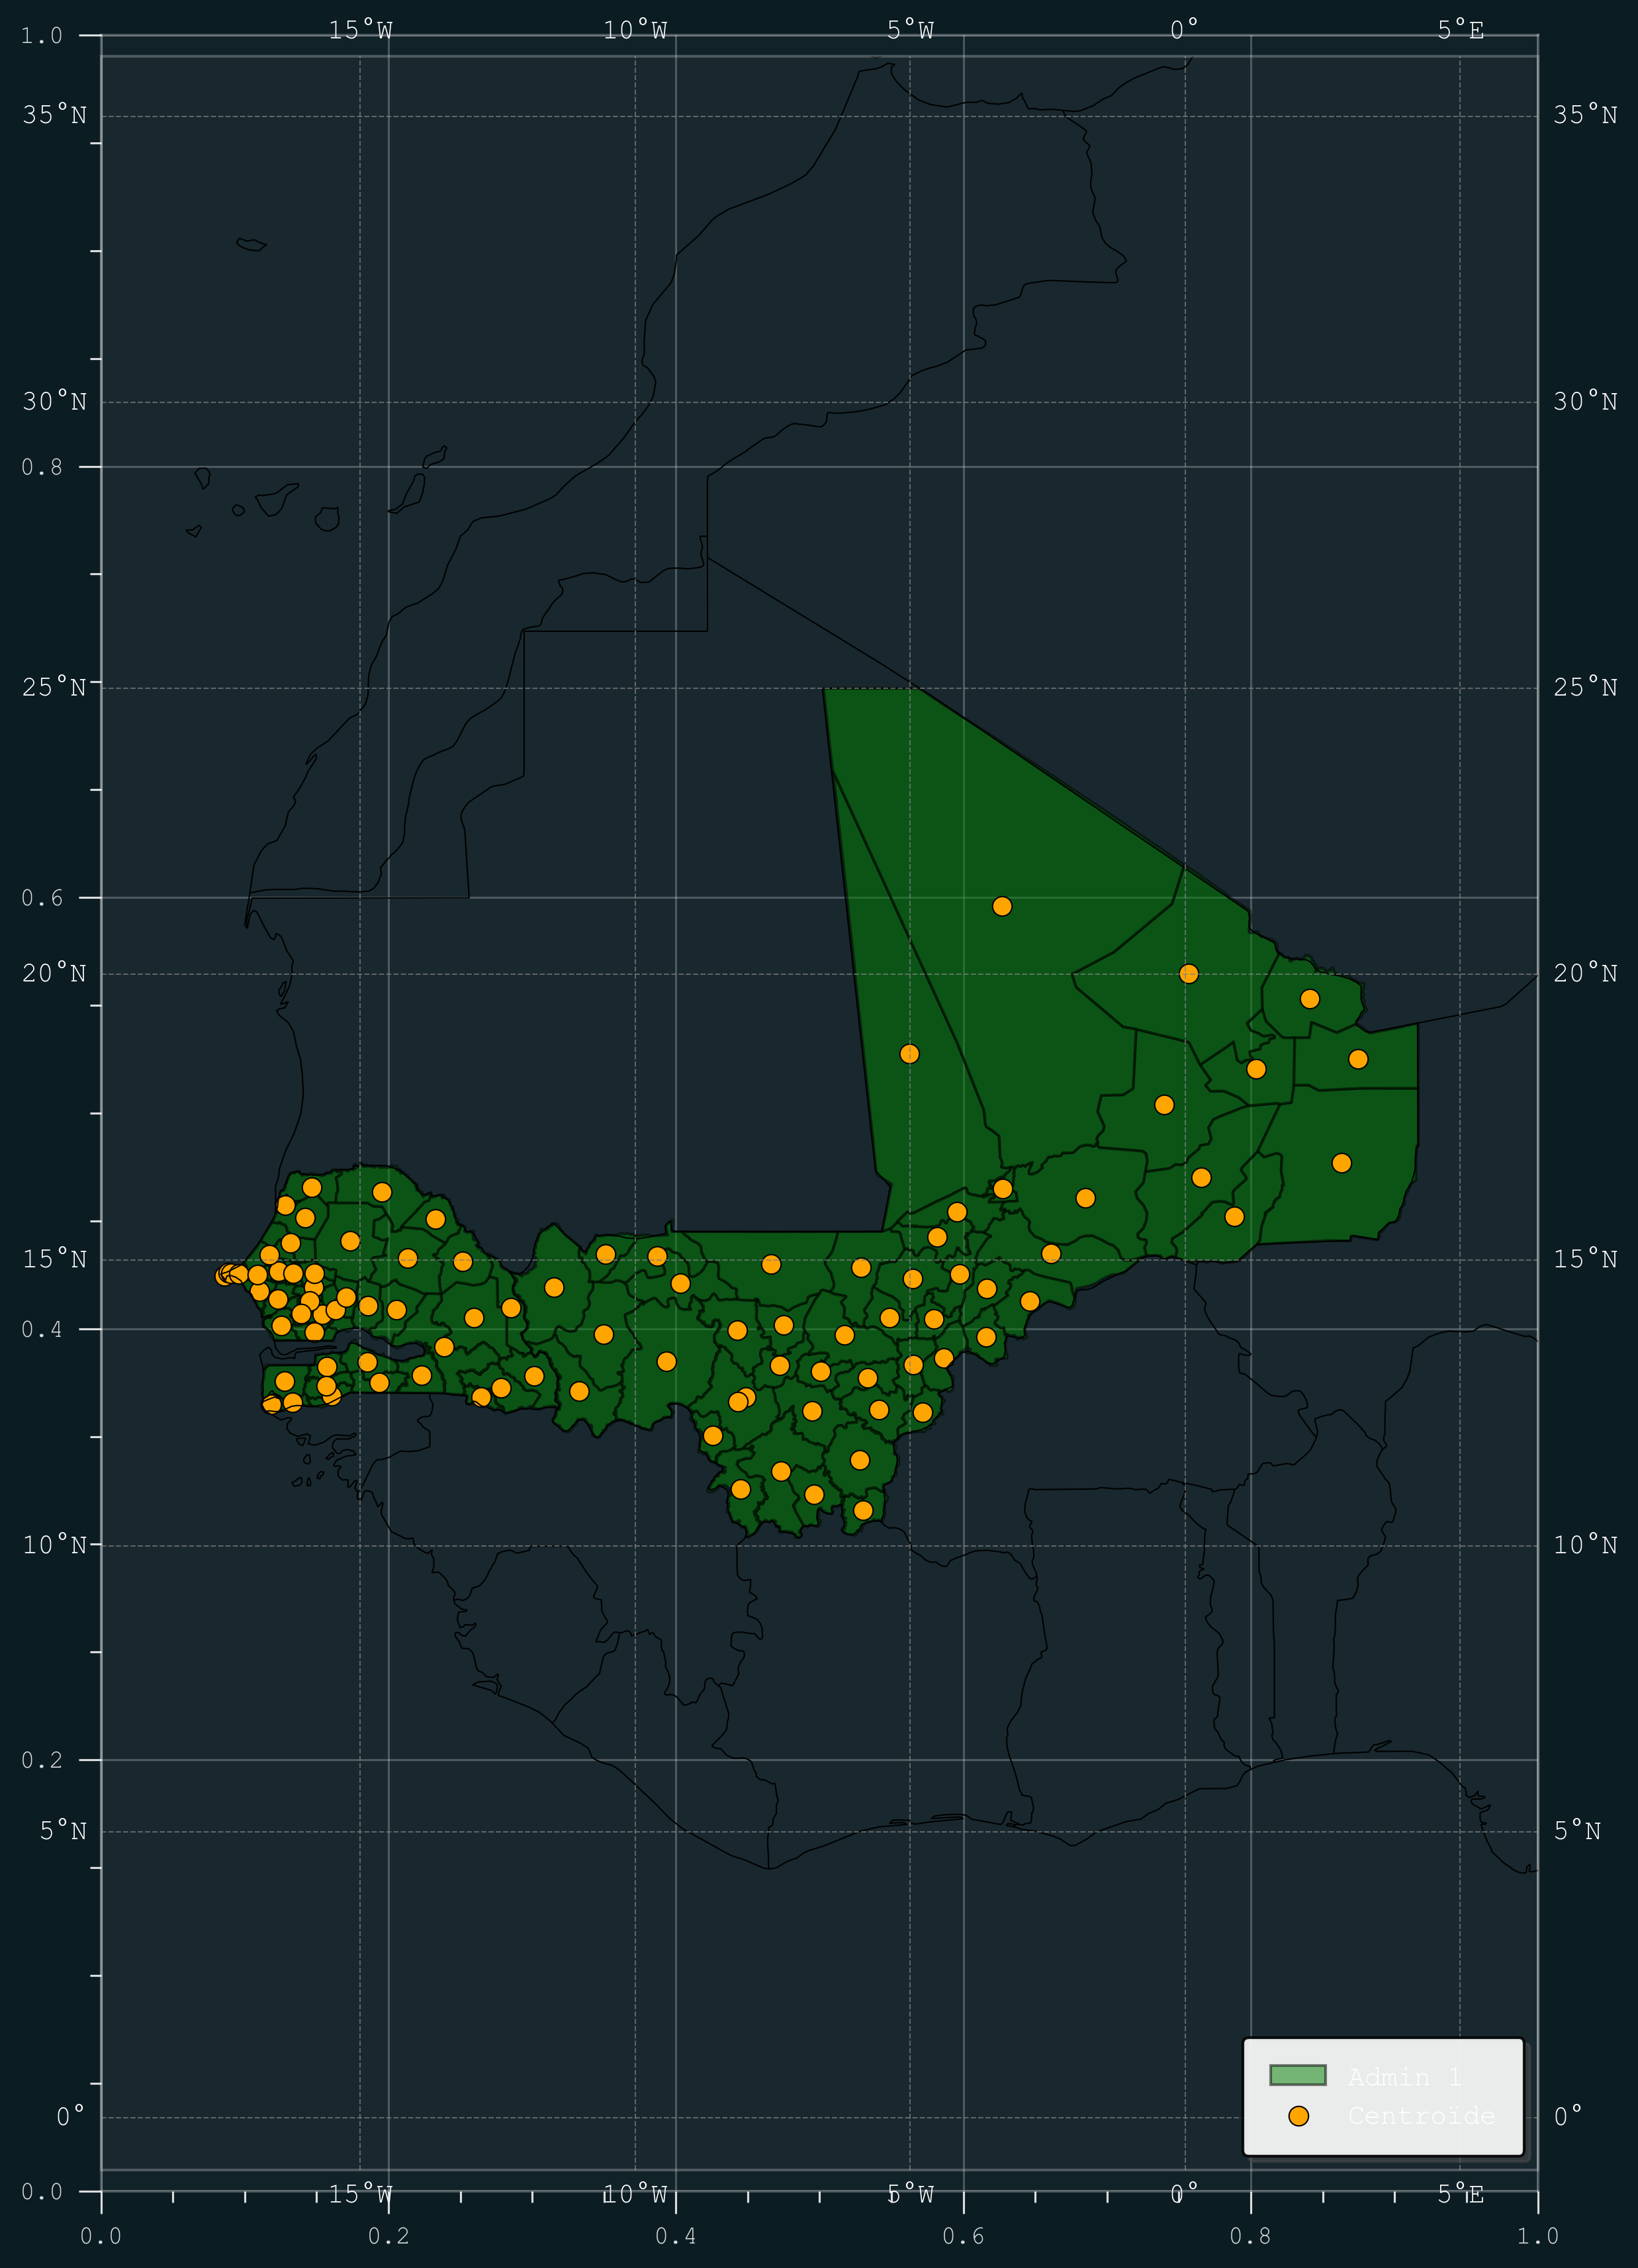

In [ ]:
carte5=Map(figsize="A4",title="")
carte5.add_layer(data_sen_mali,label="Admin 1")
centroide_sen_mal=centroids(data_sen_mali)
carte5.add_layer(centroide_sen_mal,color="orange", label="Centroïde")
carte5.legend_presets(loc="lower right")
carte5.set_paper(paper_format="A4",orientation="portrait")
carte5.add_gridlines()
carte5.show()

In [ ]:
from cartograpy.data import *

In [ ]:
bound=GeoBoundaries()

In [ ]:
sp_civ=bound.adm("civ","ADM3")

In [ ]:
sp_civ.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-3.70082 6.77977, -3.70178 6.77844, ...",Abengourou,,97208781B79507402496729,CIV,ADM3
1,"POLYGON ((-3.96967 5.4647, -3.97217 5.46854, -...",Abidjan,,97208781B76519329112770,CIV,ADM3
2,"POLYGON ((-4.84054 6.86701, -4.84342 6.86519, ...",Abigui,,97208781B41403758936369,CIV,ADM3
3,"POLYGON ((-3.0803 5.5548, -3.07958 5.55622, -3...",Aboisso,,97208781B20708403365114,CIV,ADM3
4,"POLYGON ((-3.32485 5.6594, -3.32224 5.65922, -...",Aboisso-ComoÃ©,,97208781B41857222319985,CIV,ADM3


In [ ]:
sp_kani=sp_civ[sp_civ.shapeName.str.contains('gu', na=False)]
sp_kani

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
2,"POLYGON ((-4.84054 6.86701, -4.84342 6.86519, ...",Abigui,,97208781B41403758936369,CIV,ADM3
24,"POLYGON ((-4.49744 5.99231, -4.4767 5.97783, -...",AnanguiÃ©,,97208781B49129051138126,CIV,ADM3
46,"POLYGON ((-4.09527 5.69145, -4.11565 5.68691, ...",AzaguiÃ©,,97208781B59572608879127,CIV,ADM3
78,"POLYGON ((-6.22383 10.21544, -6.24 10.21949, -...",BlessÃ©guÃ©,,97208781B7480480215844,CIV,ADM3
86,"POLYGON ((-6.34749 6.65211, -6.3822 6.69054, -...",BoguÃ©dia,,97208781B79422301254172,CIV,ADM3
92,"POLYGON ((-4.307 7.89914, -4.30491 7.88068, -4...",BonguÃ©ra,,97208781B71726194632813,CIV,ADM3
127,"POLYGON ((-3.43765 5.76758, -3.43613 5.77562, ...",Danguira,,97208781B77036551275855,CIV,ADM3
196,"POLYGON ((-6.50328 6.6814, -6.50306 6.68972, -...",GboguhÃ©,,97208781B99583832672895,CIV,ADM3
203,"POLYGON ((-7.09079 5.88828, -7.08778 5.66635, ...",Gnanmangui,,97208781B99390674922981,CIV,ADM3
226,"POLYGON ((-4.26586 5.79485, -4.28192 5.78237, ...",GuessiguiÃ©,,97208781B66947853400658,CIV,ADM3
